# TF-IDF Analysis by Time Frame

Analyzes how dominant keywords shift over time by computing TF-IDF scores per time period.

**Approach:** The preprocessed dataset dropped the `date` column, so we retrieve it
from the raw dataset and merge it back using the `url` column as the join key.

**Pipeline:**
1. Load raw dataset (1001 rows, has `date`) and preprocessed dataset (999 rows)
2. Merge `date` from raw into preprocessed via `url`/`link` join
3. Group articles by month/quarter
4. Compute TF-IDF per period

In [1]:
!pip install nltk Sastrawi pandas scikit-learn matplotlib seaborn -q


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import re

from sklearn.feature_extraction.text import TfidfVectorizer

import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded.")

Libraries loaded.


## 1. Load & Merge Datasets

In [3]:
# ADJUST THESE PATHS to match your project structure
RAW_PATH = "../../dataset/raw_dataset.csv"                          # raw dataset with 'date' column
PREPROCESSED_PATH = "../../preprocessed/dataset_preprocessed_bert.csv"  # preprocessed dataset

# Load raw dataset (has date column)
df_raw = pd.read_csv(RAW_PATH)
print(f"Raw dataset      : {len(df_raw)} rows")
print(f"Raw columns      : {list(df_raw.columns)}")

# Load preprocessed dataset
df_prep = pd.read_csv(PREPROCESSED_PATH)
df_prep = df_prep.dropna(subset=['konten_preprocessed'])
print(f"Preprocessed     : {len(df_prep)} rows")
print(f"Prep columns     : {list(df_prep.columns)}")

Raw dataset      : 1001 rows
Raw columns      : ['date', 'url', 'title', 'konten']
Preprocessed     : 999 rows
Prep columns     : ['url', 'judul', 'konten', 'manual sentiment', 'konten_length', 'konten_preprocessed']


In [5]:
# ---- Identify the matching columns ----
# Raw dataset uses 'link' or 'url', preprocessed uses 'url'
# ADJUST these column names if they differ in your files

RAW_URL_COL = 'url'    # column name for URL in raw dataset
RAW_DATE_COL = 'date'   # column name for date in raw dataset
PREP_URL_COL = 'url'    # column name for URL in preprocessed dataset

# Normalize URLs for matching (strip whitespace, lowercase)
df_raw['_join_url'] = df_raw[RAW_URL_COL].astype(str).str.strip().str.lower()
df_prep['_join_url'] = df_prep[PREP_URL_COL].astype(str).str.strip().str.lower()

# Extract only date from raw dataset for merge
df_date_map = df_raw[['_join_url', RAW_DATE_COL]].drop_duplicates(subset=['_join_url'])
df_date_map = df_date_map.rename(columns={RAW_DATE_COL: 'date'})

# Merge
df = df_prep.merge(df_date_map, on='_join_url', how='left')
df = df.drop(columns=['_join_url'])

# Stats
n_matched = df['date'].notna().sum()
n_missing = df['date'].isna().sum()
print(f"\nDate merge results:")
print(f"  Matched   : {n_matched}")
print(f"  No match  : {n_missing}")

if n_missing > 0:
    print(f"\n  Note: {n_missing} articles could not be matched.")
    print(f"  This may happen if URLs were modified during preprocessing.")
    print(f"  Consider matching on 'judul'/'title' as fallback.")


Date merge results:
  Matched   : 999
  No match  : 0


In [6]:
# Parse date column and create time grouping columns
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df_dated = df[df['date'].notna()].copy()

df_dated['year_month'] = df_dated['date'].dt.to_period('M')
df_dated['quarter'] = df_dated['date'].dt.to_period('Q')

print(f"Articles with valid date: {len(df_dated)} / {len(df)}")
print(f"Date range: {df_dated['date'].min().strftime('%Y-%m-%d')} to {df_dated['date'].max().strftime('%Y-%m-%d')}")
print(f"\nArticles per month:")
print(df_dated['year_month'].value_counts().sort_index())
print(f"\nArticles per quarter:")
print(df_dated['quarter'].value_counts().sort_index())

Articles with valid date: 999 / 999
Date range: 2025-01-20 to 2026-03-06

Articles per month:
year_month
2025-01     29
2025-02     99
2025-03     98
2025-04    526
2025-05    169
2025-06     63
2025-07      5
2025-08      1
2025-09      1
2025-10      2
2025-11      1
2026-01      3
2026-02      1
2026-03      1
Freq: M, Name: count, dtype: int64

Articles per quarter:
quarter
2025Q1    226
2025Q2    758
2025Q3      7
2025Q4      3
2026Q1      5
Freq: Q-DEC, Name: count, dtype: int64


### (Optional) Fallback: Merge by Title

If URL matching missed some articles, try matching by article title as a fallback.

In [7]:
# Uncomment and run this cell if you have many unmatched articles

# # Identify unmatched rows
# unmatched = df[df['date'].isna()].copy()
# print(f"Unmatched articles: {len(unmatched)}")
#
# if len(unmatched) > 0:
#     # Raw title column name (adjust if needed)
#     RAW_TITLE_COL = 'title'
#     PREP_TITLE_COL = 'judul'
#
#     df_raw['_join_title'] = df_raw[RAW_TITLE_COL].astype(str).str.strip().str.lower()
#     unmatched['_join_title'] = unmatched[PREP_TITLE_COL].astype(str).str.strip().str.lower()
#
#     title_map = df_raw[['_join_title', RAW_DATE_COL]].drop_duplicates(subset=['_join_title'])
#     title_map = title_map.rename(columns={RAW_DATE_COL: 'date_fallback'})
#
#     merged = unmatched.merge(title_map, on='_join_title', how='left')
#     recovered = merged['date_fallback'].notna().sum()
#     print(f"Recovered via title match: {recovered}")
#
#     # Apply fallback dates
#     for idx, row in merged[merged['date_fallback'].notna()].iterrows():
#         df.loc[idx, 'date'] = row['date_fallback']
#
#     # Recompute df_dated
#     df['date'] = pd.to_datetime(df['date'], errors='coerce')
#     df_dated = df[df['date'].notna()].copy()
#     df_dated['year_month'] = df_dated['date'].dt.to_period('M')
#     df_dated['quarter'] = df_dated['date'].dt.to_period('Q')
#     print(f"Total articles with date now: {len(df_dated)}")

## 2. Preprocessing

In [8]:
stopword_factory = StopWordRemoverFactory()
indonesian_stopwords = set(stopword_factory.get_stop_words())

custom_stopwords = {
    'yang', 'dan', 'di', 'dari', 'untuk', 'pada', 'dengan',
    'ini', 'itu', 'ke', 'dalam', 'adalah', 'juga', 'tidak',
    'akan', 'ada', 'atau', 'bisa', 'sudah', 'lebih', 'oleh',
    'hal', 'saat', 'dapat', 'telah', 'mereka', 'saya', 'kami',
    'kita', 'hanya', 'seperti', 'tentang', 'antara', 'lain',
    'maka', 'jika', 'bagi', 'pun', 'lagi', 'masih', 'ia',
    'dia', 'anda', 'kata', 'ujar', 'ucap', 'tutur', 'sebut'
}
all_stopwords = indonesian_stopwords.union(custom_stopwords)

PUBLISHER_NOISE = sorted([
    'bloomberg news bloomberg', 'bloomberg news', 'bloomberg com',
    'reuters thomson reuters', 'thomson reuters', 'reuters com',
    'associated press', 'the associated press',
    'bloomberg technoz jakarta', 'cnbc indonesia', 'cnn indonesia',
    'kompas com', 'kompas tv', 'tribunnews com', 'detik com',
    'detikfinance', 'detikcom', 'liputan6 com', 'tempo co',
    'kontan co id', 'bisnis com', 'bisnis indonesia',
    'katadata co id', 'katadata', 'antara news', 'antaranews com',
    'okezone com', 'sindonews com', 'tirto id', 'kumparan com',
    'baca juga', 'baca selengkapnya', 'simak juga',
    'hak cipta', 'all rights reserved', 'copyright',
    'unduh aplikasi', 'download aplikasi',
    'sindonews berita terbaru', 'channel sindonews berita',
    'whatsapp channel sindonews', 'berita terbaru hari',
    'konten melakukan crawling', 'continue with content',
    'gambas video cnn', 'von der leyen', 'ursula von der',
    'federal reserve the', 'reserve the fed',
], key=len, reverse=True)


def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    for phrase in PUBLISHER_NOISE:
        text = text.replace(phrase, ' ')
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in all_stopwords and len(t) >= 3]
    return ' '.join(tokens)


print("Preprocessing articles...")
df_dated['cleaned_text'] = df_dated['konten_preprocessed'].apply(preprocess_text)
df_dated = df_dated[df_dated['cleaned_text'].str.strip() != '']
print(f"Done! {len(df_dated)} articles preprocessed.")

Preprocessing articles...
Done! 999 articles preprocessed.


## 3. TF-IDF per Time Frame

In [9]:
def tfidf_analysis(corpus, top_n=20):
    corpus_clean = [doc for doc in corpus if doc.strip()]
    if len(corpus_clean) < 2:
        return pd.DataFrame(columns=['Term', 'TF-IDF Score'])
    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=10000,
        sublinear_tf=True,
    )
    tfidf_matrix = vectorizer.fit_transform(corpus_clean)
    features = vectorizer.get_feature_names_out()
    mean_scores = tfidf_matrix.mean(axis=0).A1
    result = pd.DataFrame({'Term': features, 'TF-IDF Score': mean_scores})
    return result.sort_values('TF-IDF Score', ascending=False).head(top_n).reset_index(drop=True)

print("TF-IDF function ready.")

TF-IDF function ready.


In [18]:
# ADJUST: Choose time granularity
TIME_COL = 'quarter'  # Options: 'year_month' for monthly, 'quarter' for quarterly
TOP_N = 20

periods = sorted(df_dated[TIME_COL].unique())
print(f"Time granularity: {TIME_COL}")
print(f"Periods found: {len(periods)}\n")

tfidf_per_period = {}

for period in periods:
    subset = df_dated[df_dated[TIME_COL] == period]
    if len(subset) < 2:
        print(f"  Skipping {period} (only {len(subset)} article(s))")
        continue
    
    corpus = subset['cleaned_text'].tolist()
    df_result = tfidf_analysis(corpus, TOP_N)
    df_result['Period'] = str(period)
    df_result['Article Count'] = len(subset)
    tfidf_per_period[str(period)] = df_result
    
    print(f"--- {period} ({len(subset)} articles) ---")
    print(df_result[['Term', 'TF-IDF Score']].head(10).to_string(index=False))
    print()

Time granularity: quarter
Periods found: 5

--- 2025Q1 (226 articles) ---
       Term  TF-IDF Score
      tarif      0.040625
      trump      0.037133
     negara      0.028988
perdagangan      0.026383
      impor      0.025747
      china      0.025632
  kebijakan      0.025536
     kanada      0.025383
    amerika      0.025123
    meksiko      0.023559

--- 2025Q2 (758 articles) ---
       Term  TF-IDF Score
      tarif      0.038974
      trump      0.032173
  indonesia      0.030544
     negara      0.030389
      china      0.024766
perdagangan      0.024518
  kebijakan      0.024340
      impor      0.023191
    amerika      0.023158
     persen      0.022646

--- 2025Q3 (7 articles) ---
     Term  TF-IDF Score
indonesia      0.043365
 industri      0.038115
   global      0.030638
 nasional      0.029163
    tarif      0.028967
  ekonomi      0.028332
   negeri      0.028277
   ekspor      0.027713
kebijakan      0.027555
  menjadi      0.027360

--- 2025Q4 (3 articles) ---
 

## 4. Visualization

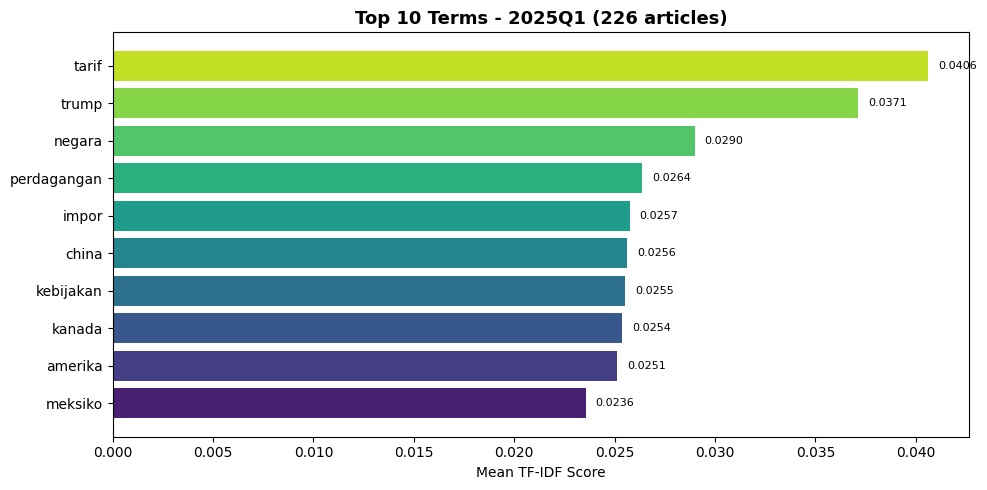

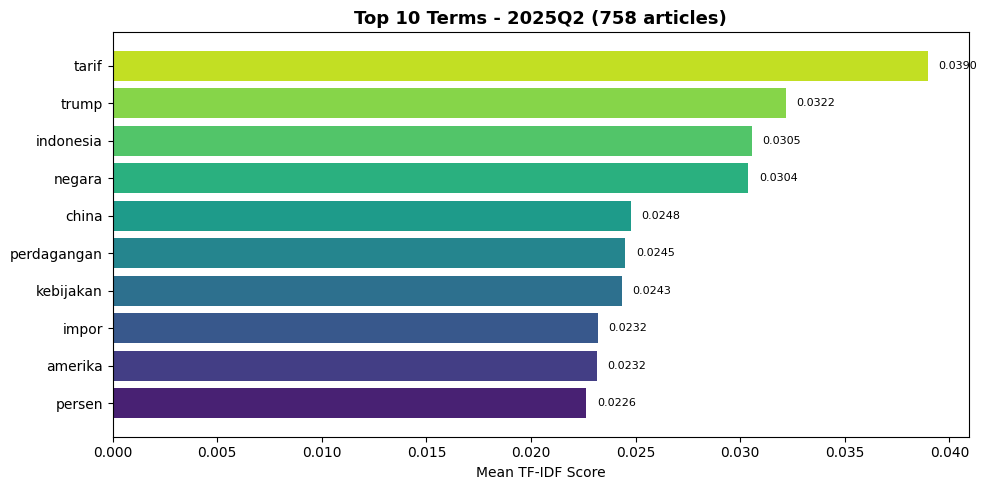

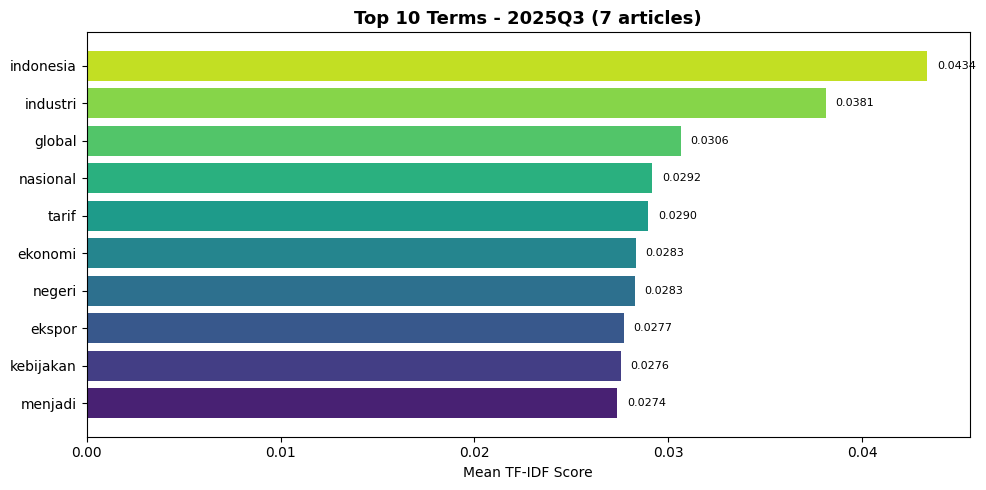

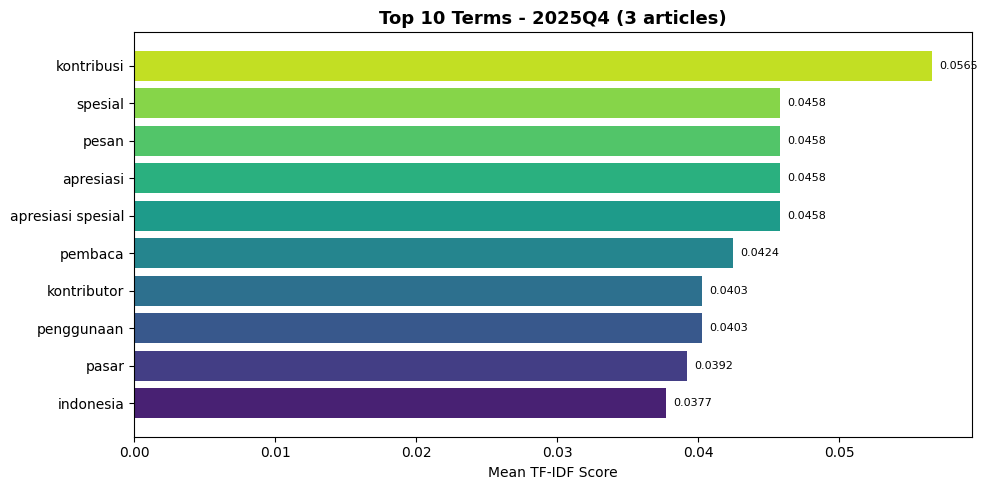

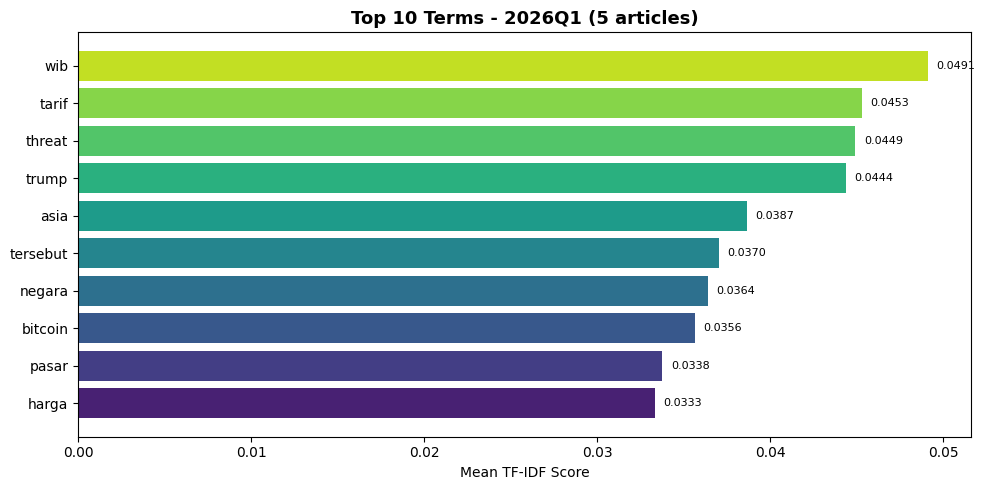

In [19]:
for period, df_p in tfidf_per_period.items():
    data = df_p.head(10).iloc[::-1]
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = sns.color_palette('viridis', len(data))
    ax.barh(data['Term'], data['TF-IDF Score'], color=colors)
    ax.set_xlabel('Mean TF-IDF Score')
    ax.set_title(f'Top 10 Terms - {period} ({data["Article Count"].iloc[0]} articles)',
                 fontsize=13, fontweight='bold')
    for i, val in enumerate(data['TF-IDF Score']):
        ax.text(val + 0.0005, i, f'{val:.4f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

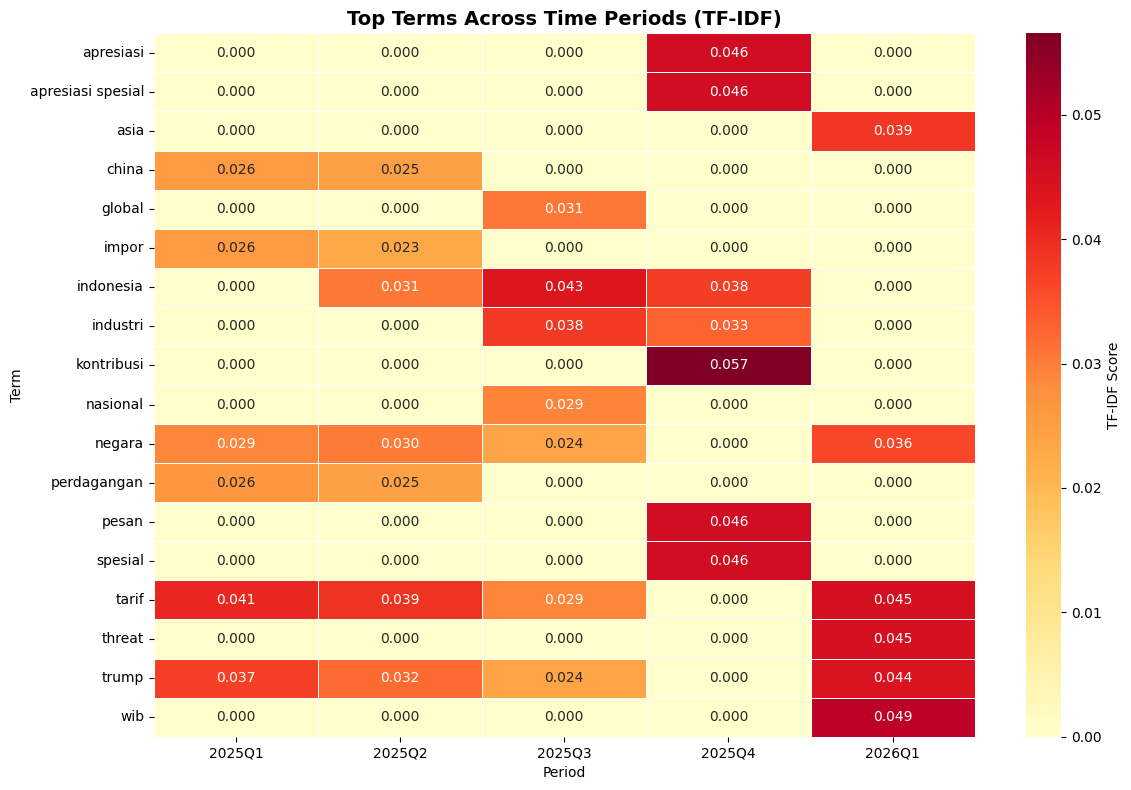

In [20]:
# Timeline heatmap: top terms across all periods
all_top_terms = set()
for df_p in tfidf_per_period.values():
    all_top_terms.update(df_p['Term'].head(5).tolist())

all_top_terms = sorted(all_top_terms)
period_labels = sorted(tfidf_per_period.keys())

heatmap_data = pd.DataFrame(0.0, index=all_top_terms, columns=period_labels)
for period, df_p in tfidf_per_period.items():
    for _, row in df_p.iterrows():
        if row['Term'] in heatmap_data.index:
            heatmap_data.loc[row['Term'], period] = row['TF-IDF Score']

fig, ax = plt.subplots(figsize=(max(12, len(period_labels) * 1.5),
                                max(8, len(all_top_terms) * 0.4)))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'TF-IDF Score'})
ax.set_title('Top Terms Across Time Periods (TF-IDF)', fontsize=14, fontweight='bold')
ax.set_xlabel('Period')
ax.set_ylabel('Term')
plt.tight_layout()
plt.show()

## 5. Export to CSV

In [21]:
import os

OUTPUT_DIR = "../../outputs/tfidf_timeframe"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Combined file
all_periods = pd.concat(tfidf_per_period.values(), ignore_index=True)
all_periods.to_csv(f"{OUTPUT_DIR}/tfidf_by_timeframe.csv", index=False)
print(f"Exported: tfidf_by_timeframe.csv ({len(all_periods)} rows)")

# Per-period files
for period, df_p in tfidf_per_period.items():
    safe_name = str(period).replace(' ', '_')
    df_p.to_csv(f"{OUTPUT_DIR}/tfidf_{safe_name}.csv", index=False)

print(f"Exported {len(tfidf_per_period)} individual period files")

# Article date mapping
df_dated[['url', 'judul', 'date', 'year_month', 'quarter']].to_csv(
    f"{OUTPUT_DIR}/article_dates.csv", index=False)
print(f"Exported: article_dates.csv ({len(df_dated)} rows)")

print(f"\nAll files: {os.path.abspath(OUTPUT_DIR)}")

Exported: tfidf_by_timeframe.csv (100 rows)
Exported 5 individual period files
Exported: article_dates.csv (999 rows)

All files: d:\Code\kelompok-7-pba\outputs\tfidf_timeframe
